In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Splitting and validation
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RepeatedKFold,
    cross_validate,
    GridSearchCV
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Statistical diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

In [3]:
file_path = r"D:\MSC THESIS AAVAS\AFTER MID DEFENSE\Final data with IRI\data_for_modeling_with_IRI.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Sheet1"
)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (130, 10)

Columns:
['SN', 'V85 Speed', 'Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Left Shoulder Type', 'Right Shoulder Width', 'Right Shoulder Type', 'IRI']


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type,IRI
0,1,57.0,1.27,inf,5.5,0.9,Gravel,0.9,Gravel,3.70
1,2,33.0,2.92,46.0,5.5,0.9,Gravel,0.9,Gravel,4.51
2,3,43.0,7.97,inf,5.5,0.9,Gravel,0.9,Gravel,4.39
3,4,48.0,2.07,inf,5.5,0.9,Gravel,0.9,Gravel,4.69
4,5,36.0,1.21,16.0,5.5,0.9,Gravel,0.9,Gravel,5.57


In [4]:
df.columns = df.columns.str.strip()

In [5]:
categorical_columns = [
    "Left Shoulder Type",
    "Right Shoulder Type"
]

for col in categorical_columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

In [6]:
print("LEFT SHOULDER TYPE")
print(df["Left Shoulder Type"].value_counts())

print("\nRIGHT SHOULDER TYPE")
print(df["Right Shoulder Type"].value_counts())

LEFT SHOULDER TYPE
Left Shoulder Type
Gravel    57
Absent    41
Paved     32
Name: count, dtype: int64

RIGHT SHOULDER TYPE
Right Shoulder Type
Gravel    49
Paved     42
Absent    39
Name: count, dtype: int64


In [7]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print(
    "\nDuplicate observations:",
    df.drop(columns=["SN"]).duplicated().sum()
)

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    130 non-null    int64  
 1   V85 Speed             130 non-null    float64
 2   Gradient              130 non-null    float64
 3   Radius of Curve       130 non-null    float64
 4   Carriageway Width     130 non-null    float64
 5   Left Shoulder Width   130 non-null    float64
 6   Left Shoulder Type    130 non-null    str    
 7   Right Shoulder Width  130 non-null    float64
 8   Right Shoulder Type   130 non-null    str    
 9   IRI                   130 non-null    float64
dtypes: float64(7), int64(1), str(2)
memory usage: 10.3 KB
None

Missing values:
SN                      0
V85 Speed               0
Gradient                0
Radius of Curve         0
Carriageway Width       0
Left Shoulder Width     0
Left Shoulder Type      0
Right Shoulder Width    0
Right

In [8]:
print(
    "Tangent observations:",
    np.isinf(df["Radius of Curve"]).sum()
)

print(
    "Curve observations:",
    np.isfinite(df["Radius of Curve"]).sum()
)

Tangent observations: 46
Curve observations: 84


In [9]:
df["Radius_Model"] = df["Radius of Curve"].replace(
    [np.inf, -np.inf],
    1500.0
)

In [10]:
display(
    df[
        [
            "Radius of Curve",
            "Radius_Model"
        ]
    ].head(30)
)

,Radius of Curve,Radius_Model
0,inf,1500.0
1,46.0,46.0
2,inf,1500.0
3,inf,1500.0
4,16.0,16.0
5,inf,1500.0
6,150.0,150.0
7,inf,1500.0
8,inf,1500.0
9,25.0,25.0


In [11]:
print(
    df["Radius_Model"].describe()
)

count     130.000000
mean      595.953846
std       675.207219
min        15.000000
25%        55.000000
50%       150.000000
75%      1500.000000
max      1500.000000
Name: Radius_Model, dtype: float64


In [12]:
print(
    df["Gradient"].describe()
)

print(
    "Negative gradients:",
    (df["Gradient"] < 0).sum()
)

count    130.000000
mean       3.819304
std        2.585841
min        0.100000
25%        1.365000
50%        3.625000
75%        5.975000
max       10.000000
Name: Gradient, dtype: float64
Negative gradients: 0


In [13]:
target = "V85 Speed"

In [14]:
numerical_features = [
    "Gradient",
    "Radius_Model",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

In [15]:
categorical_features = [
    "Left Shoulder Type",
    "Right Shoulder Type"
]

In [16]:
X = df[
    numerical_features +
    categorical_features
].copy()

y = df[target].copy()

print("X:", X.shape)
print("y:", y.shape)

display(X.head())

X: (130, 8)
y: (130,)


,Gradient,Radius_Model,Carriageway Width,Left Shoulder Width,Right Shoulder Width,IRI,Left Shoulder Type,Right Shoulder Type
0,1.27,1500.0,5.5,0.9,0.9,3.70,Gravel,Gravel
1,2.92,46.0,5.5,0.9,0.9,4.51,Gravel,Gravel
2,7.97,1500.0,5.5,0.9,0.9,4.39,Gravel,Gravel
3,2.07,1500.0,5.5,0.9,0.9,4.69,Gravel,Gravel
4,1.21,16.0,5.5,0.9,0.9,5.57,Gravel,Gravel


In [17]:
descriptive_columns = [
    "V85 Speed",
    "Gradient",
    "Radius_Model",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

descriptive_stats = (
    df[descriptive_columns]
    .describe()
    .T
)

descriptive_stats["CV (%)"] = (
    descriptive_stats["std"] /
    descriptive_stats["mean"]
) * 100

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,CV (%)
V85 Speed,130.0,47.178077,10.399495,24.00,42.0000,47.250,55.3750,74.00,22.043067
Gradient,130.0,3.819304,2.585841,0.10,1.3650,3.625,5.9750,10.00,67.704510
Radius_Model,130.0,595.953846,675.207219,15.00,55.0000,150.000,1500.0000,1500.00,113.298576
Carriageway Width,130.0,6.246592,0.949410,4.70,5.3895,7.000,7.0000,8.00,15.198854
Left Shoulder Width,130.0,0.474692,0.392229,0.00,0.0000,0.500,0.9000,1.13,82.628081
Right Shoulder Width,130.0,0.484308,0.385513,0.00,0.0000,0.500,0.9000,1.18,79.600785
IRI,130.0,6.991385,2.252709,3.63,5.0600,6.865,9.1525,12.05,32.221212


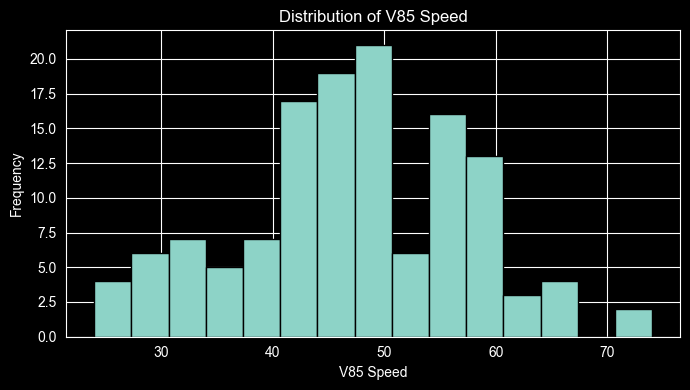

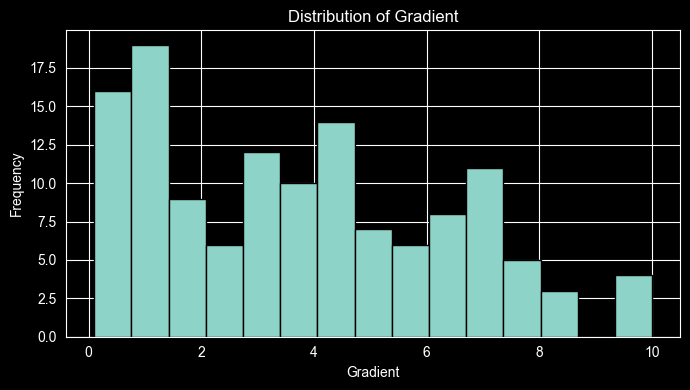

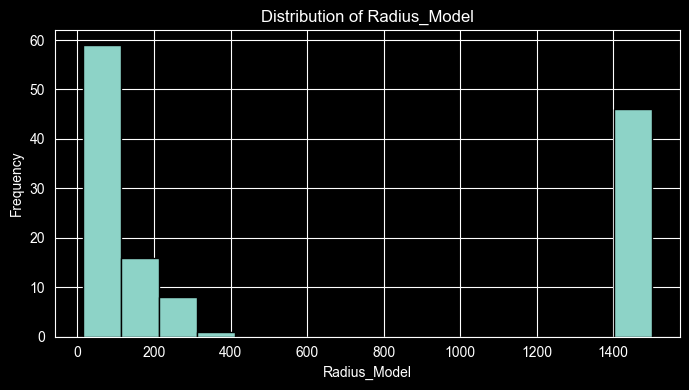

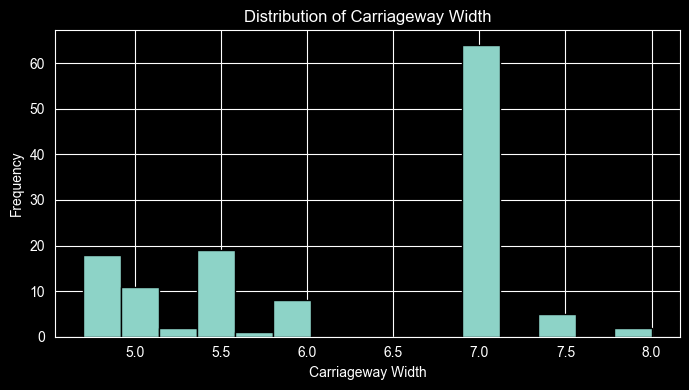

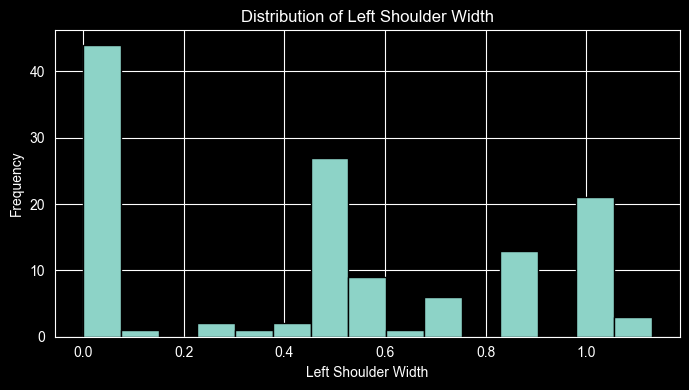

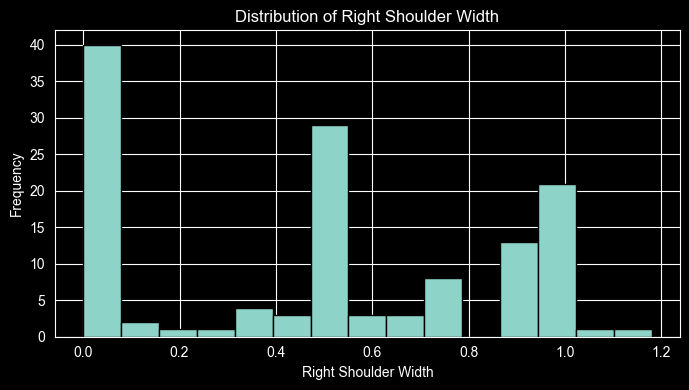

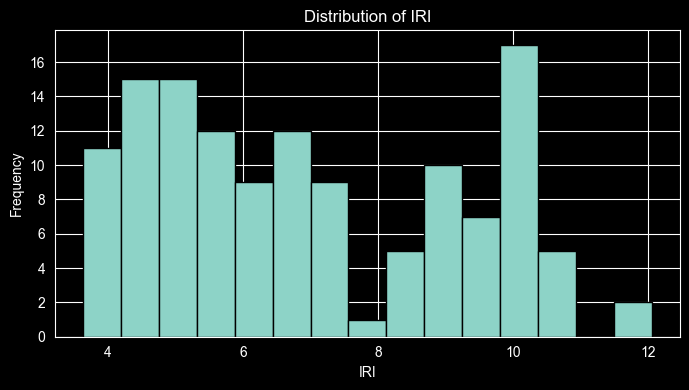

In [18]:
for column in descriptive_columns:

    plt.figure(figsize=(7, 4))

    plt.hist(
        df[column],
        bins=15,
        edgecolor="black"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")

    plt.tight_layout()
    plt.show()

In [19]:
correlation_columns = [
    "V85 Speed",
    "Gradient",
    "Radius_Model",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

corr_matrix = df[correlation_columns].corr(
    method="pearson"
)

display(corr_matrix.round(3))

,V85 Speed,Gradient,Radius_Model,Carriageway Width,Left Shoulder Width,Right Shoulder Width,IRI
V85 Speed,1.000,-0.009,0.469,0.077,0.073,0.002,0.024
Gradient,-0.009,1.000,-0.150,-0.175,-0.211,-0.221,0.016
Radius_Model,0.469,-0.150,1.000,0.039,0.213,0.070,-0.061
Carriageway Width,0.077,-0.175,0.039,1.000,0.019,-0.242,0.582
Left Shoulder Width,0.073,-0.211,0.213,0.019,1.000,0.247,-0.211
Right Shoulder Width,0.002,-0.221,0.070,-0.242,0.247,1.000,-0.207
IRI,0.024,0.016,-0.061,0.582,-0.211,-0.207,1.000


In [20]:
v85_correlation = (
    corr_matrix["V85 Speed"]
    .sort_values(ascending=False)
)

display(v85_correlation)

V85 Speed               1.000000
Radius_Model            0.469073
Carriageway Width       0.076669
Left Shoulder Width     0.072844
IRI                     0.023664
Right Shoulder Width    0.001674
Gradient               -0.009296
Name: V85 Speed, dtype: float64

,V85 Speed,Gradient,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Radius of Curve,IRI
V85 Speed,1.00,-0.01,0.08,0.07,0.00,0.47,0.02
Gradient,-0.01,1.00,-0.18,-0.21,-0.22,-0.15,0.02
Carriageway Width,0.08,-0.18,1.00,0.02,-0.24,0.04,0.58
Left Shoulder Width,0.07,-0.21,0.02,1.00,0.25,0.21,-0.21
Right Shoulder Width,0.00,-0.22,-0.24,0.25,1.00,0.07,-0.21
Radius of Curve,0.47,-0.15,0.04,0.21,0.07,1.00,-0.06
IRI,0.02,0.02,0.58,-0.21,-0.21,-0.06,1.00


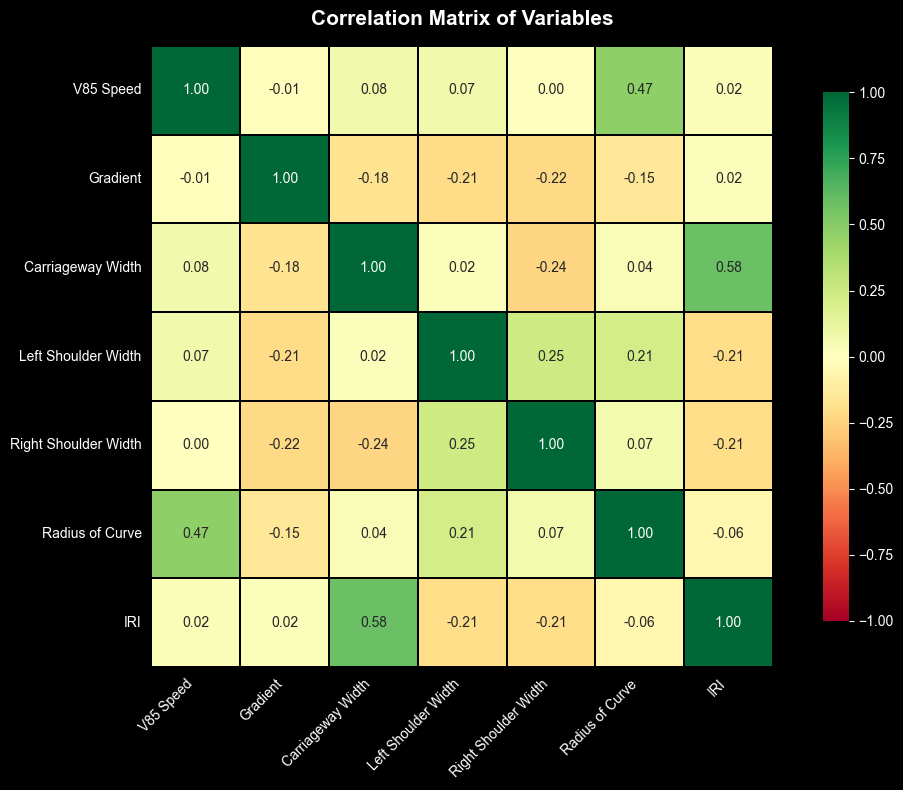

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------------------
# VARIABLES FOR CORRELATION ANALYSIS
# -----------------------------------------------------

correlation_data = df[
    [
        "V85 Speed",
        "Gradient",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "Radius_Model",
        "IRI"
    ]
].copy()

# Rename only for nicer figure labels
correlation_data = correlation_data.rename(
    columns={
        "Radius_Model": "Radius of Curve"
    }
)

# -----------------------------------------------------
# PEARSON CORRELATION MATRIX
# -----------------------------------------------------

corr_matrix = correlation_data.corr(
    method="pearson"
)

display(
    corr_matrix.round(2)
)


# -----------------------------------------------------
# CORRELATION HEATMAP
# -----------------------------------------------------

plt.figure(
    figsize=(11, 8)
)

sns.heatmap(
    corr_matrix,

    # Show correlation values
    annot=True,

    # Two decimal places
    fmt=".2f",

    # Green = positive
    # Yellow = near zero
    # Red = negative
    cmap="RdYlGn",

    # Correlation always ranges from -1 to +1
    vmin=-1,
    vmax=1,

    # Zero placed at centre of colour scale
    center=0,

    # Black borders like your example
    linewidths=1.2,
    linecolor="black",

    # Keep cells square
    square=True,

    # Annotation appearance
    annot_kws={
        "size": 10
    },

    # Colour bar
    cbar_kws={
        "shrink": 0.85,
        "ticks": [
            -1,
            -0.75,
            -0.50,
            -0.25,
            0,
            0.25,
            0.50,
            0.75,
            1
        ]
    }
)

# -----------------------------------------------------
# TITLE AND LABEL FORMATTING
# -----------------------------------------------------

plt.title(
    "Correlation Matrix of Variables",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

plt.tight_layout()

plt.show()

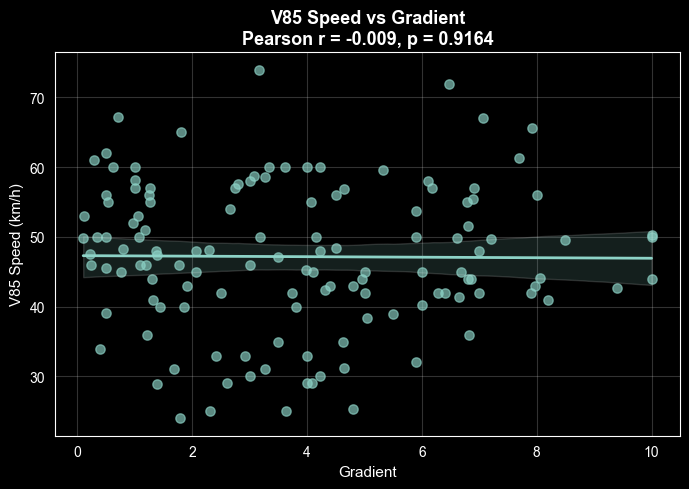

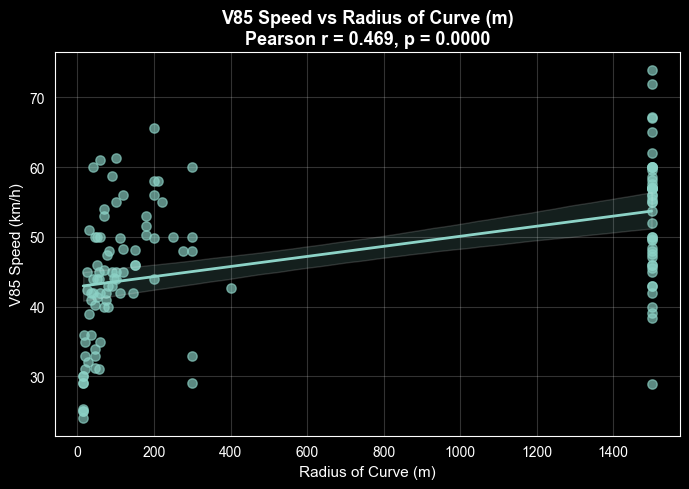

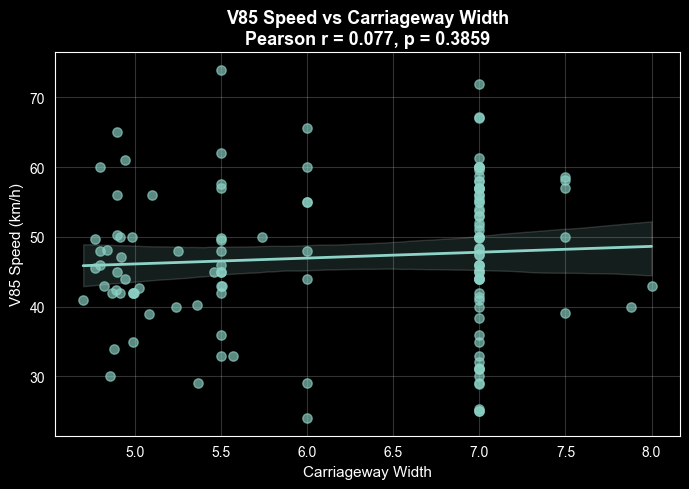

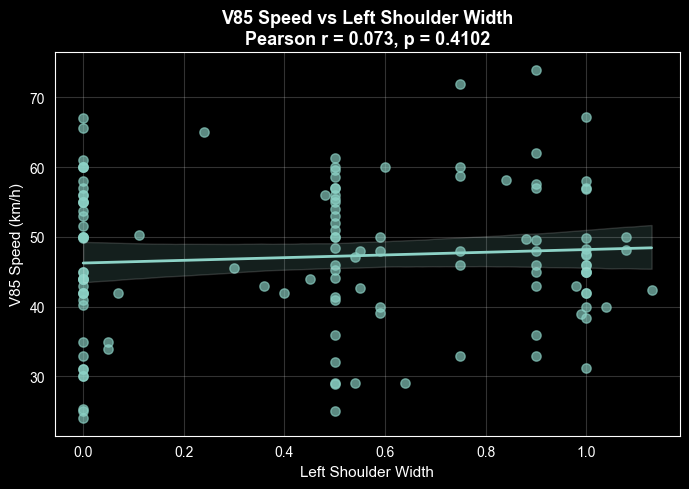

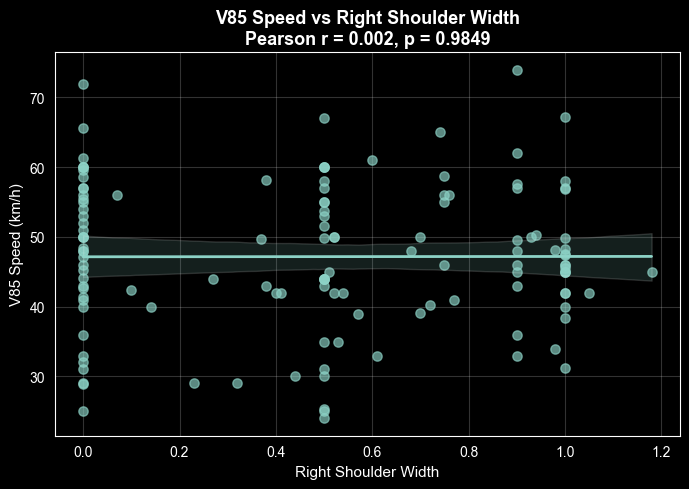

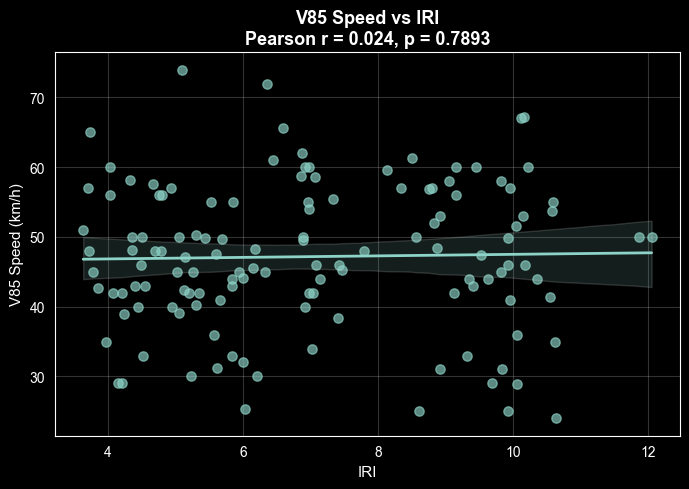

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

relationship_features = [
    "Gradient",
    "Radius_Model",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

for feature in relationship_features:

    # Pearson correlation
    r, p = pearsonr(
        df[feature],
        df["V85 Speed"]
    )

    plt.figure(figsize=(7, 5))

    sns.regplot(
        data=df,
        x=feature,
        y="V85 Speed",
        scatter_kws={
            "alpha": 0.65,
            "s": 45
        },
        line_kws={
            "linewidth": 2
        },
        ci=95
    )

    # Better label for radius
    xlabel = (
        "Radius of Curve (m)"
        if feature == "Radius_Model"
        else feature
    )

    plt.xlabel(
        xlabel,
        fontsize=11
    )

    plt.ylabel(
        "V85 Speed (km/h)",
        fontsize=11
    )

    plt.title(
        f"V85 Speed vs {xlabel}\n"
        f"Pearson r = {r:.3f}, p = {p:.4f}",
        fontsize=13,
        fontweight="bold"
    )

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

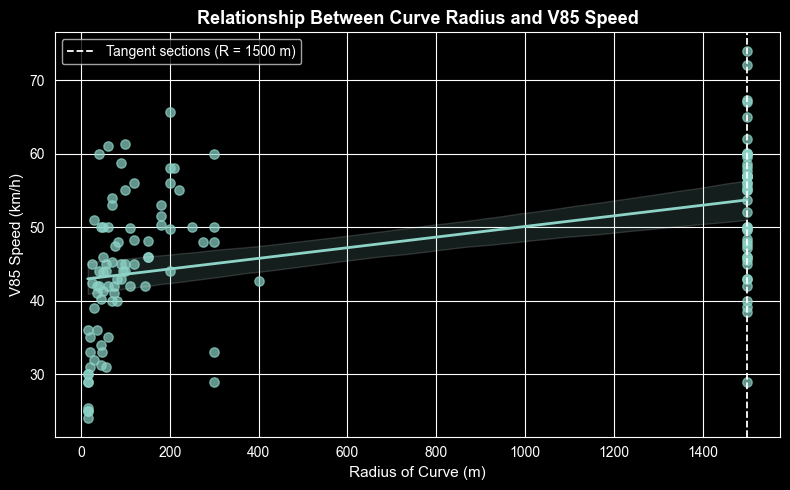

In [73]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Radius_Model",
    y="V85 Speed",
    scatter_kws={
        "alpha": 0.7,
        "s": 45
    },
    line_kws={
        "linewidth": 2
    },
    ci=95
)

plt.axvline(
    x=1500,
    linestyle="--",
    linewidth=1.3,
    label="Tangent sections (R = 1500 m)"
)

plt.xlabel(
    "Radius of Curve (m)",
    fontsize=11
)

plt.ylabel(
    "V85 Speed (km/h)",
    fontsize=11
)

plt.title(
    "Relationship Between Curve Radius and V85 Speed",
    fontsize=13,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

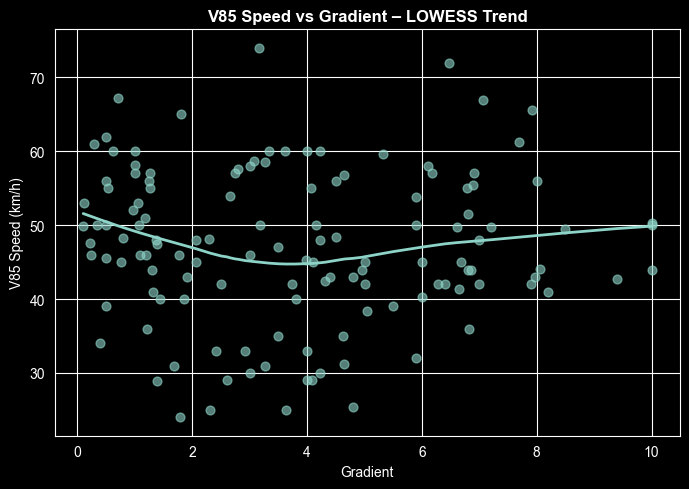

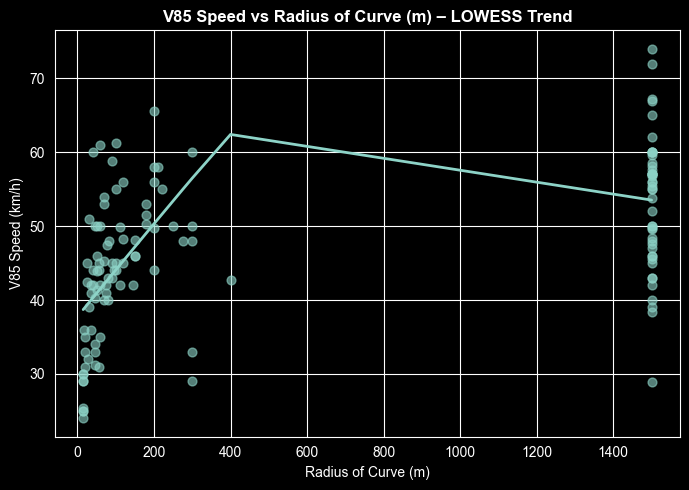

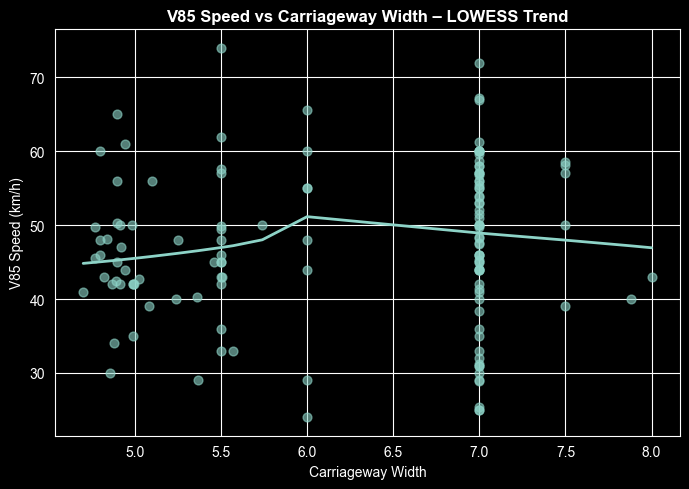

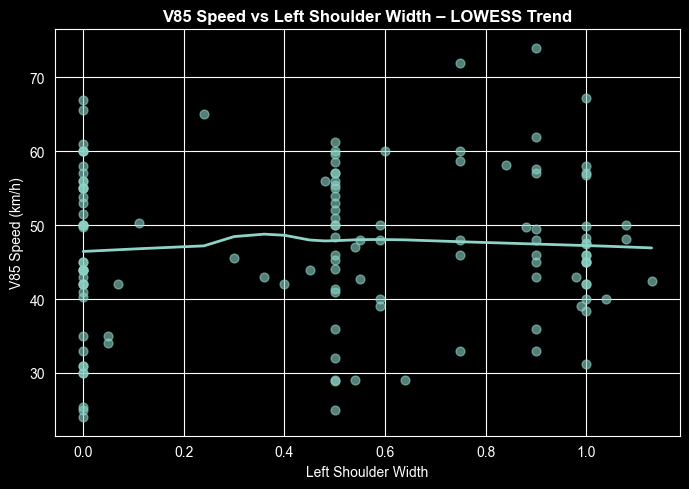

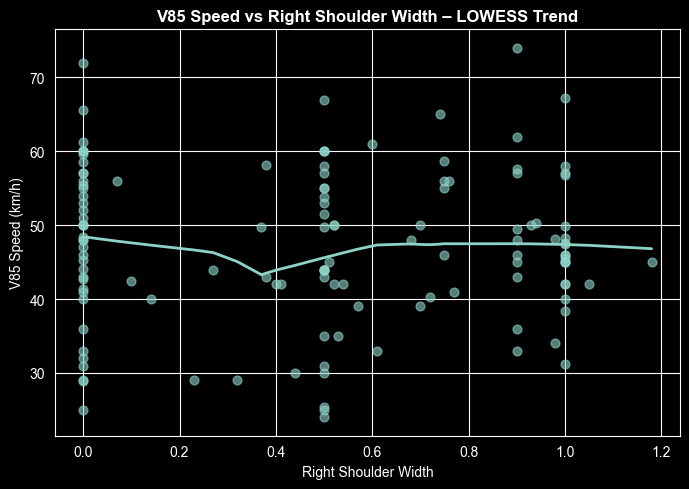

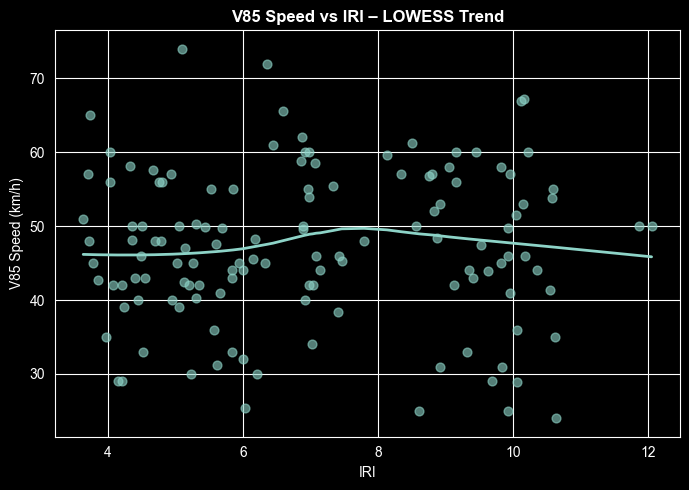

In [74]:
for feature in relationship_features:

    plt.figure(figsize=(7, 5))

    sns.regplot(
        data=df,
        x=feature,
        y="V85 Speed",

        # nonlinear smooth relationship
        lowess=True,

        scatter_kws={
            "alpha": 0.60,
            "s": 40
        },

        line_kws={
            "linewidth": 2
        }
    )

    xlabel = (
        "Radius of Curve (m)"
        if feature == "Radius_Model"
        else feature
    )

    plt.xlabel(xlabel)
    plt.ylabel("V85 Speed (km/h)")

    plt.title(
        f"V85 Speed vs {xlabel} – LOWESS Trend",
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

In [22]:
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

# Numerical predictors only
vif_numeric_data = df[
    [
        "Gradient",
        "Radius_Model",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "IRI"
    ]
].copy()

# Add intercept
X_vif_numeric = sm.add_constant(
    vif_numeric_data
)

# Calculate VIF
vif_numeric = pd.DataFrame()

vif_numeric["Variable"] = X_vif_numeric.columns

vif_numeric["VIF"] = [
    variance_inflation_factor(
        X_vif_numeric.values,
        i
    )
    for i in range(X_vif_numeric.shape[1])
]

# Remove intercept from displayed table
vif_numeric = (
    vif_numeric[
        vif_numeric["Variable"] != "const"
    ]
    .sort_values(
        by="VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    vif_numeric.round(3)
)

,Variable,VIF
0,Carriageway Width,1.729
1,IRI,1.651
2,Right Shoulder Width,1.205
3,Left Shoulder Width,1.203
4,Gradient,1.164
5,Radius_Model,1.062


In [23]:
vif_full_data = df[
    [
        "Gradient",
        "Radius_Model",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "IRI",
        "Left Shoulder Type",
        "Right Shoulder Type"
    ]
].copy()

In [24]:
vif_full_data = pd.get_dummies(
    vif_full_data,
    columns=[
        "Left Shoulder Type",
        "Right Shoulder Type"
    ],
    drop_first=True,
    dtype=int
)

display(
    vif_full_data.head()
)

,Gradient,Radius_Model,Carriageway Width,Left Shoulder Width,Right Shoulder Width,IRI,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
0,1.27,1500.0,5.5,0.9,0.9,3.70,1,0,1,0
1,2.92,46.0,5.5,0.9,0.9,4.51,1,0,1,0
2,7.97,1500.0,5.5,0.9,0.9,4.39,1,0,1,0
3,2.07,1500.0,5.5,0.9,0.9,4.69,1,0,1,0
4,1.21,16.0,5.5,0.9,0.9,5.57,1,0,1,0


In [25]:
X_vif_full = sm.add_constant(
    vif_full_data
)

vif_full = pd.DataFrame()

vif_full["Variable"] = X_vif_full.columns

vif_full["VIF"] = [
    variance_inflation_factor(
        X_vif_full.values,
        i
    )
    for i in range(
        X_vif_full.shape[1]
    )
]

vif_full = (
    vif_full[
        vif_full["Variable"] != "const"
    ]
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    vif_full.round(3)
)

,Variable,VIF
0,Left Shoulder Type_Gravel,6.230
1,Right Shoulder Type_Paved,5.714
2,Right Shoulder Type_Gravel,5.234
3,Left Shoulder Type_Paved,4.982
4,Left Shoulder Width,4.664
5,Right Shoulder Width,4.413
6,Carriageway Width,1.834
7,IRI,1.805
8,Gradient,1.216
9,Radius_Model,1.092


In [26]:
df["Average Shoulder Width"] = (
    df["Left Shoulder Width"] +
    df["Right Shoulder Width"]
) / 2

In [27]:
display(
    df[
        [
            "Left Shoulder Width",
            "Right Shoulder Width",
            "Average Shoulder Width"
        ]
    ].head(10)
)

,Left Shoulder Width,Right Shoulder Width,Average Shoulder Width
0,0.9,0.9,0.9
1,0.9,0.9,0.9
2,0.9,0.9,0.9
3,0.9,0.9,0.9
4,0.9,0.9,0.9
5,0.9,0.9,0.9
6,0.9,0.9,0.9
7,0.9,0.9,0.9
8,0.9,0.9,0.9
9,0.9,0.9,0.9


In [28]:
display(
    df[
        [
            "Left Shoulder Width",
            "Right Shoulder Width",
            "Average Shoulder Width"
        ]
    ].head(25)
)

,Left Shoulder Width,Right Shoulder Width,Average Shoulder Width
0,0.90,0.90,0.900
1,0.90,0.90,0.900
2,0.90,0.90,0.900
3,0.90,0.90,0.900
4,0.90,0.90,0.900
5,0.90,0.90,0.900
6,0.90,0.90,0.900
7,0.90,0.90,0.900
8,0.90,0.90,0.900
9,0.90,0.90,0.900


In [29]:
check = np.isclose(
    df["Average Shoulder Width"],
    (
        df["Left Shoulder Width"] +
        df["Right Shoulder Width"]
    ) / 2
)

print("All averages calculated correctly:", check.all())

All averages calculated correctly: True


In [30]:
average_shoulder_vif_data = df[
    [
        "Gradient",
        "Radius_Model",
        "Carriageway Width",
        "Average Shoulder Width",
        "IRI"
    ]
].copy()

In [31]:
print("Missing values:")
print(average_shoulder_vif_data.isnull().sum())

print(
    "\nInfinite values:",
    np.isinf(
        average_shoulder_vif_data
    ).sum()
)

Missing values:
Gradient                  0
Radius_Model              0
Carriageway Width         0
Average Shoulder Width    0
IRI                       0
dtype: int64

Infinite values: Gradient                  0
Radius_Model              0
Carriageway Width         0
Average Shoulder Width    0
IRI                       0
dtype: int64


In [32]:
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

X_vif_average = sm.add_constant(
    average_shoulder_vif_data
)

vif_average = pd.DataFrame()

vif_average["Variable"] = X_vif_average.columns

vif_average["VIF"] = [
    variance_inflation_factor(
        X_vif_average.values,
        i
    )
    for i in range(
        X_vif_average.shape[1]
    )
]

# Remove the constant from the final table
vif_average = (
    vif_average[
        vif_average["Variable"] != "const"
    ]
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    vif_average.round(3)
)

,Variable,VIF
0,IRI,1.610
1,Carriageway Width,1.604
2,Average Shoulder Width,1.192
3,Gradient,1.156
4,Radius_Model,1.051


In [34]:
r_avg = df[
    "V85 Speed"
].corr(
    df["Average Shoulder Width"]
)

print(
    f"Correlation between V85 and Average Shoulder Width = {r_avg:.3f}"
)

Correlation between V85 and Average Shoulder Width = 0.048


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

case1_features = [
    "Gradient",
    "Radius_Model",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

X_case1 = df[case1_features].copy()
y = df["V85 Speed"].copy()

print("X shape:", X_case1.shape)
print("y shape:", y.shape)

display(X_case1.head())

X shape: (130, 6)
y shape: (130,)


,Gradient,Radius_Model,Carriageway Width,Left Shoulder Width,Right Shoulder Width,IRI
0,1.27,1500.0,5.5,0.9,0.9,3.70
1,2.92,46.0,5.5,0.9,0.9,4.51
2,7.97,1500.0,5.5,0.9,0.9,4.39
3,2.07,1500.0,5.5,0.9,0.9,4.69
4,1.21,16.0,5.5,0.9,0.9,5.57


In [51]:
from sklearn.model_selection import train_test_split

all_indices = df.index.to_numpy()

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42
)

X_train = X_case1.loc[train_idx].copy()
X_test = X_case1.loc[test_idx].copy()

y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

print("Training observations:", len(X_train))
print("Testing observations :", len(X_test))

Training observations: 104
Testing observations : 26


In [52]:
split_summary = pd.DataFrame({
    "Full Mean": X_case1.mean(),
    "Train Mean": X_train.mean(),
    "Test Mean": X_test.mean()
})

display(split_summary.round(3))

print("\nV85 means")
print("Full :", round(y.mean(), 3))
print("Train:", round(y_train.mean(), 3))
print("Test :", round(y_test.mean(), 3))

,Full Mean,Train Mean,Test Mean
Gradient,3.819,3.789,3.940
Radius_Model,595.954,628.731,464.846
Carriageway Width,6.247,6.214,6.378
Left Shoulder Width,0.475,0.474,0.477
Right Shoulder Width,0.484,0.482,0.493
IRI,6.991,6.875,7.459



V85 means
Full : 47.178
Train: 47.436
Test : 46.146


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

mlr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [54]:
from sklearn.model_selection import RepeatedKFold

mlr_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

In [55]:
from sklearn.model_selection import cross_validate

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

mlr_cv_scores = cross_validate(
    mlr_pipeline,
    X_train,
    y_train,
    cv=mlr_cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

In [56]:
mlr_cv_results = pd.DataFrame({
    "Metric": [
        "R²",
        "RMSE",
        "MAE"
    ],

    "Mean Validation": [
        mlr_cv_scores["test_r2"].mean(),
        -mlr_cv_scores["test_rmse"].mean(),
        -mlr_cv_scores["test_mae"].mean()
    ],

    "SD Validation": [
        mlr_cv_scores["test_r2"].std(),
        mlr_cv_scores["test_rmse"].std(),
        mlr_cv_scores["test_mae"].std()
    ],

    "Mean Training": [
        mlr_cv_scores["train_r2"].mean(),
        -mlr_cv_scores["train_rmse"].mean(),
        -mlr_cv_scores["train_mae"].mean()
    ]
})

display(
    mlr_cv_results.round(3)
)

,Metric,Mean Validation,SD Validation,Mean Training
0,R²,0.074,0.241,0.262
1,RMSE,9.689,1.318,9.028
2,MAE,7.809,1.268,7.210


In [57]:
mlr_fold_results = pd.DataFrame({
    "R2": mlr_cv_scores["test_r2"],
    "RMSE": -mlr_cv_scores["test_rmse"],
    "MAE": -mlr_cv_scores["test_mae"]
})

display(
    mlr_fold_results.describe().round(3)
)

,R2,RMSE,MAE
count,50.000,50.000,50.000
mean,0.074,9.689,7.809
std,0.243,1.332,1.281
min,-0.597,6.762,5.028
25%,-0.083,8.770,6.886
50%,0.133,9.898,7.899
75%,0.272,10.542,8.692
max,0.417,12.293,10.573


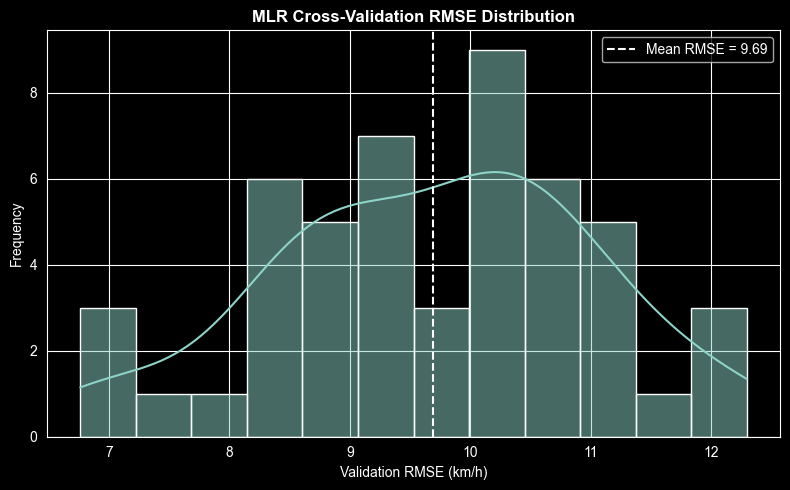

In [58]:
plt.figure(figsize=(8, 5))

sns.histplot(
    mlr_fold_results["RMSE"],
    bins=12,
    kde=True
)

plt.axvline(
    mlr_fold_results["RMSE"].mean(),
    linestyle="--",
    label=f'Mean RMSE = {mlr_fold_results["RMSE"].mean():.2f}'
)

plt.xlabel("Validation RMSE (km/h)")
plt.ylabel("Frequency")

plt.title(
    "MLR Cross-Validation RMSE Distribution",
    fontweight="bold"
)

plt.legend()
plt.tight_layout()
plt.show()

In [59]:
import statsmodels.api as sm

X_train_ols = sm.add_constant(
    X_train
)

mlr_ols = sm.OLS(
    y_train,
    X_train_ols
).fit()

print(
    mlr_ols.summary()
)

                            OLS Regression Results                            
Dep. Variable:              V85 Speed   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     5.473
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           6.50e-05
Time:                        17:33:55   Log-Likelihood:                -377.34
No. Observations:                 104   AIC:                             768.7
Df Residuals:                      97   BIC:                             787.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   40.0113 

In [60]:
mlr_coefficients = pd.DataFrame({
    "Variable": mlr_ols.params.index,
    "Coefficient": mlr_ols.params.values,
    "Std Error": mlr_ols.bse.values,
    "t Statistic": mlr_ols.tvalues.values,
    "p Value": mlr_ols.pvalues.values,
    "CI Lower 95%": mlr_ols.conf_int()[0].values,
    "CI Upper 95%": mlr_ols.conf_int()[1].values
})

display(
    mlr_coefficients.round(4)
)

,Variable,Coefficient,Std Error,t Statistic,p Value,CI Lower 95%,CI Upper 95%
0,const,40.0113,7.7918,5.1351,0.0000,24.5467,55.4758
1,Gradient,0.3573,0.3870,0.9233,0.3581,-0.4107,1.1254
2,Radius_Model,0.0078,0.0014,5.4748,0.0000,0.0049,0.0106
3,Carriageway Width,0.3777,1.2818,0.2947,0.7689,-2.1664,2.9218
4,Left Shoulder Width,0.9587,2.6199,0.3659,0.7152,-4.2410,6.1584
5,Right Shoulder Width,-0.7604,2.6895,-0.2827,0.7780,-6.0983,4.5775
6,IRI,-0.1804,0.5300,-0.3404,0.7343,-1.2322,0.8714


In [61]:
print("Training R²:")
print(round(mlr_ols.rsquared, 4))

print("\nAdjusted R²:")
print(round(mlr_ols.rsquared_adj, 4))

print("\nF-statistic:")
print(round(mlr_ols.fvalue, 4))

print("\nF-test p-value:")
print(mlr_ols.f_pvalue)

print("\nAIC:")
print(round(mlr_ols.aic, 3))

print("\nBIC:")
print(round(mlr_ols.bic, 3))

Training R²:
0.2529

Adjusted R²:
0.2067

F-statistic:
5.473

F-test p-value:
6.5005321192351e-05

AIC:
768.675

BIC:
787.186


In [62]:
params = mlr_ols.params

equation = (
    f"V85 = {params['const']:.4f}"
    f" + ({params['Gradient']:.4f} × Gradient)"
    f" + ({params['Radius_Model']:.4f} × Radius)"
    f" + ({params['Carriageway Width']:.4f} × Carriageway Width)"
    f" + ({params['Left Shoulder Width']:.4f} × Left Shoulder Width)"
    f" + ({params['Right Shoulder Width']:.4f} × Right Shoulder Width)"
    f" + ({params['IRI']:.4f} × IRI)"
)

print(equation)

V85 = 40.0113 + (0.3573 × Gradient) + (0.0078 × Radius) + (0.3777 × Carriageway Width) + (0.9587 × Left Shoulder Width) + (-0.7604 × Right Shoulder Width) + (-0.1804 × IRI)


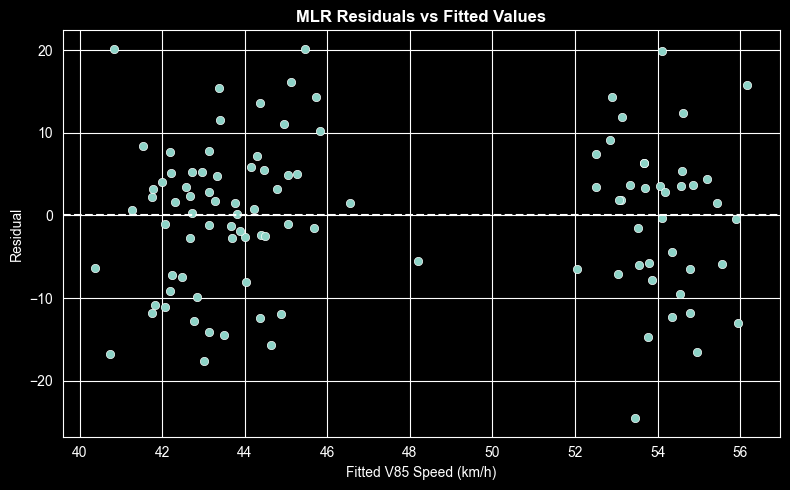

In [63]:
mlr_fitted = mlr_ols.fittedvalues
mlr_residuals = mlr_ols.resid

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=mlr_fitted,
    y=mlr_residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted V85 Speed (km/h)")
plt.ylabel("Residual")

plt.title(
    "MLR Residuals vs Fitted Values",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

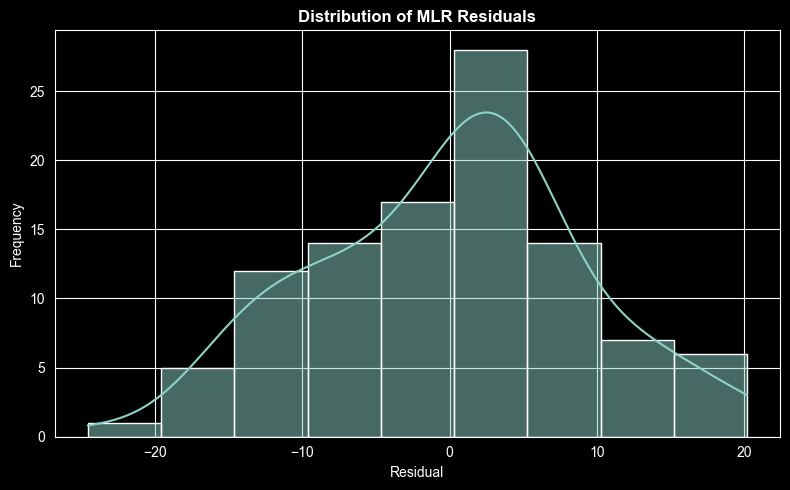

In [64]:
plt.figure(figsize=(8, 5))

sns.histplot(
    mlr_residuals,
    kde=True
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title(
    "Distribution of MLR Residuals",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

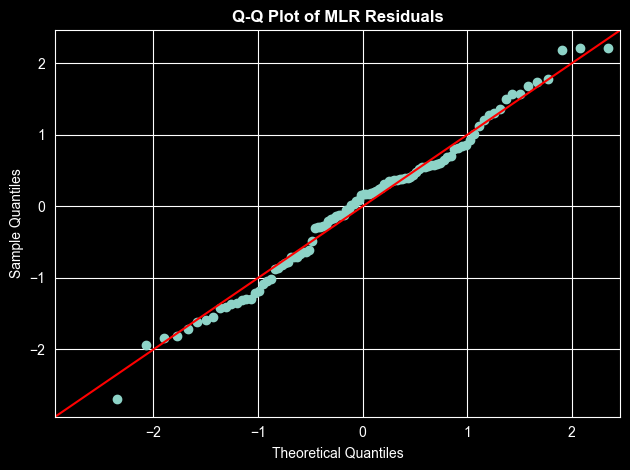

In [65]:
sm.qqplot(
    mlr_residuals,
    line="45",
    fit=True
)

plt.title(
    "Q-Q Plot of MLR Residuals",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [66]:
from scipy.stats import shapiro

shapiro_stat, shapiro_p = shapiro(
    mlr_residuals
)

print(
    f"Shapiro-Wilk statistic = {shapiro_stat:.4f}"
)

print(
    f"p-value = {shapiro_p:.4f}"
)

Shapiro-Wilk statistic = 0.9871
p-value = 0.4138


In [67]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp = het_breuschpagan(
    mlr_residuals,
    mlr_ols.model.exog
)

bp_results = pd.DataFrame({
    "Statistic": [
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ],

    "Value": [
        bp[0],
        bp[1],
        bp[2],
        bp[3]
    ]
})

display(
    bp_results.round(4)
)

,Statistic,Value
0,LM Statistic,2.4946
1,LM p-value,0.8691
2,F Statistic,0.3973
3,F p-value,0.8791


In [68]:
mlr_influence = mlr_ols.get_influence()

cooks_d = mlr_influence.cooks_distance[0]

cook_threshold = 4 / len(X_train)

print(
    f"Cook's Distance threshold = {cook_threshold:.4f}"
)

Cook's Distance threshold = 0.0385


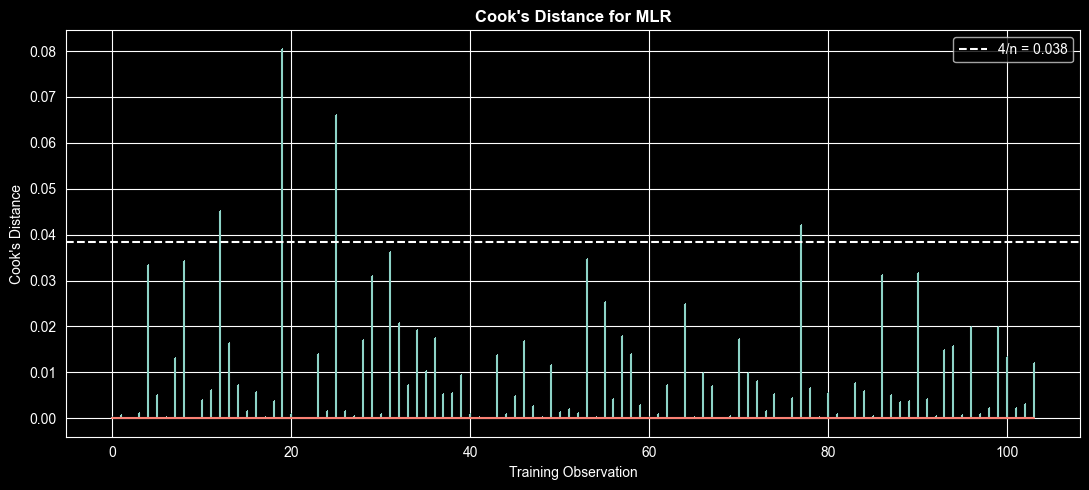

In [69]:
plt.figure(figsize=(11, 5))

plt.stem(
    range(len(cooks_d)),
    cooks_d,
    markerfmt=","
)

plt.axhline(
    cook_threshold,
    linestyle="--",
    label=f"4/n = {cook_threshold:.3f}"
)

plt.xlabel("Training Observation")
plt.ylabel("Cook's Distance")

plt.title(
    "Cook's Distance for MLR",
    fontweight="bold"
)

plt.legend()
plt.tight_layout()
plt.show()